# PROJECT :  Partie REGRESSION 
# Dataset : Life Expectancy (WHO)
 

## Dataset Source

https://www.kaggle.com/kumarajarshi/life-expectancy-who

## Dataset Information

The Global Health Observatory (GHO) data repository under World Health Organization (WHO) keeps track of the health status as well as many other related factors for all countries The data-sets are made available to public for the purpose of health data analysis. The data-set related to life expectancy, health factors for 193 countries has been collected from the same WHO data repository website and its corresponding economic data was collected from United Nation website. Among all categories of health-related factors only those critical factors were chosen which are more representative. It has been observed that in the past 15 years , there has been a huge development in health sector resulting in improvement of human mortality rates especially in the developing nations in comparison to the past 30 years.

Therefore, in this project we have considered data from year 2000-2015 for 193 countries for further analysis.On initial visual inspection of the data showed some missing values. As the data-sets were from WHO, we found no evident errors. Missing data was handled in R software by using Missmap command. The result indicated that most of the missing data was for population, Hepatitis B and GDP. The missing data were from less known countries like Vanuatu, Tonga, Togo, Cabo Verde etc. The final merged file(final dataset) consists of 22 Columns and 2938 rows which meant 20 predicting variables. All predicting variables was then divided into several broad categories: Immunization related factors, Mortality factors, Economical factors and Social factors.

## Feature Information

The dataset consists of 22 columns of which 20 are predictor variables and 2938 rows.

### Columns

1. Country: Country
2. Year: Year
3. Status: Developed or Developing status
4. Life expectancy: Life Expectancy in age
5. Adult Mortality: Adult Mortality Rates of both sexes (probability of dying between 15 and 60 years per 1000 population)
6. infant deaths: Number of Infant Deaths per 1000 population
7. Alcohol: Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol)
8. percentage expenditure: Expenditure on health as a percentage of Gross Domestic Product per capita(%)
9. Hepatitis B: Hepatitis B (HepB) immunization coverage among 1-year-olds (%)
10. Measles: Measles - number of reported cases per 1000 population
11. BMI: Average Body Mass Index of entire population
12. under-five deaths: Number of under-five deaths per 1000 population
13. Polio: Polio (Pol3) immunization coverage among 1-year-olds (%)
14. Total expenditure: General government expenditure on health as a percentage of total government expenditure (%)
15. Diphtheria: Diphtheria tetanus toxoid and pertussis (DTP3) immunization coverage among 1-year-olds (%)
16. HIV/AIDS: Deaths per 1 000 live births HIV/AIDS (0-4 years)
17. GDP: Gross Domestic Product per capita (in USD)
18. Population: Population of the country
19. thinness 1-19 years: Prevalence of thinness among children and adolescents for Age 10 to 19 (% )
20. thinness 5-9 years: Prevalence of thinness among children for Age 5 to 9(%)
21. Income composition of resources: Human Development Index in terms of income composition of resources (index ranging from 0 to 1)
22. Schooling: Number of years of Schooling(years)

## Data Loading and Initial Exploration 
### Library Imports

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer 
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn .neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , classification_report , roc_auc_score , roc_curve
import matplotlib.pyplot as plt 
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import plot_model #for model visualization

#from tensorflow.keras.layers import Dense
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.utils import plot_model #for model visualization


from warnings import filterwarnings
filterwarnings('ignore')

### Reading the Data into a pandas Dataframe 

In [2]:
df=pd.read_csv('Life Expectancy Data.csv')
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [3]:
#print number of rows and columns in the dataset

print("Number of Rows:",df.shape[0])
print("Number of Features:",df.shape[1])

Number of Rows: 2938
Number of Features: 22


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

## Missing values analysis

**Checking for NULL values in the dataset**

In [5]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

## Statistical Info for Numerical Features

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2.007519e+03,4.613841e+00,2000.00000,2004.000000,2.008000e+03,2.012000e+03,2.015000e+03
Life expectancy,2928.0,6.922493e+01,9.523867e+00,36.30000,63.100000,7.210000e+01,7.570000e+01,8.900000e+01
Adult Mortality,2928.0,1.647964e+02,1.242921e+02,1.00000,74.000000,1.440000e+02,2.280000e+02,7.230000e+02
infant deaths,2938.0,3.030395e+01,1.179265e+02,0.00000,0.000000,3.000000e+00,2.200000e+01,1.800000e+03
Alcohol,2744.0,4.602861e+00,4.052413e+00,0.01000,0.877500,3.755000e+00,7.702500e+00,1.787000e+01
percentage expenditure,2938.0,7.382513e+02,1.987915e+03,0.00000,4.685343,6.491291e+01,4.415341e+02,1.947991e+04
Hepatitis B,2385.0,8.094046e+01,2.507002e+01,1.00000,77.000000,9.200000e+01,9.700000e+01,9.900000e+01
Measles,2938.0,2.419592e+03,1.146727e+04,0.00000,0.000000,1.700000e+01,3.602500e+02,2.121830e+05
BMI,2904.0,3.832125e+01,2.004403e+01,1.00000,19.300000,4.350000e+01,5.620000e+01,8.730000e+01
under-five deaths,2938.0,4.203574e+01,1.604455e+02,0.00000,0.000000,4.000000e+00,2.800000e+01,2.500000e+03


## Exploring Categorical Features

In [7]:
df['Country'].value_counts()

Country
Afghanistan              16
Albania                  16
Algeria                  16
Angola                   16
Antigua and Barbuda      16
                         ..
Monaco                    1
Marshall Islands          1
Saint Kitts and Nevis     1
San Marino                1
Tuvalu                    1
Name: count, Length: 193, dtype: int64

In [8]:
df['Status'].value_counts()

Status
Developing    2426
Developed      512
Name: count, dtype: int64

## Data Cleaning

### Handling Missing Values

#### As the number of Missing Values is large I will use Imputing Method to fill null values with mean Value

In [9]:
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(missing_values=np.nan, strategy='mean', fill_value=None)

df['Life expectancy ']=imputer.fit_transform(df[['Life expectancy ']])
df['Adult Mortality']=imputer.fit_transform(df[['Adult Mortality']])
df['Alcohol']=imputer.fit_transform(df[['Alcohol']])
df['Hepatitis B']=imputer.fit_transform(df[['Hepatitis B']])
df[' BMI ']=imputer.fit_transform(df[[' BMI ']])
df['Polio']=imputer.fit_transform(df[['Polio']])
df['Total expenditure']=imputer.fit_transform(df[['Total expenditure']])
df['Diphtheria ']=imputer.fit_transform(df[['Diphtheria ']])
df['GDP']=imputer.fit_transform(df[['GDP']])
df['Population']=imputer.fit_transform(df[['Population']])
df[' thinness  1-19 years']=imputer.fit_transform(df[[' thinness  1-19 years']])
df[' thinness 5-9 years']=imputer.fit_transform(df[[' thinness 5-9 years']])
df['Income composition of resources']=imputer.fit_transform(df[['Income composition of resources']])
df['Schooling']=imputer.fit_transform(df[['Schooling']])

In [10]:
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

In [11]:
df = df.drop_duplicates()


 Country wise Life Expectancy over Years

#### Handling Outliers
Outliers can skew the data and manipulate the final result. Hence, we check for outliers. However, we will not remove outliers for the sake of the data being accurate. For example, it is possible that a country may have an extremely high population, but that does not mean we disconsider aand remove it from our dataset

In [12]:
# Loop through each column and create a box plot
for column in df.columns:
    fig = px.box(df, y=column, title=f'Box Plot for {column}')
    
    # Update layout to center the title and make it bold
    fig.update_layout(
        title=dict(text=f'<b>Box Plot for {column}</b>', x=0.5),
        boxmode='group'  
    )
    
    fig.show()

Data normalisation for 
'Status'

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])  # Developed=0, Developing=1


data visualisation 

In [14]:
fig=px.histogram(df,x='Life expectancy ',template='plotly_dark')
fig.show()

In [15]:
fig=px.line(df.sort_values(by='Year'),x='Year',y='Life expectancy ',animation_frame='Country',animation_group='Year',color='Country',markers=True,template='plotly_dark',title='<b> Country wise Life Expectancy over Years')
fig.show()

**Some important questions to consider in this dataset**

Visualize adult and infant mortality rates for top 10 counties with lowest life expectancy

Does Life Expectancy has positive or negative correlation with eating habits, lifestyle, exercise, smoking, drinking alcohol

What is the impact of schooling on the lifespan of humans?

In [16]:
low_life = df.groupby('Country').mean().nsmallest(10, ['Life expectancy ']).reset_index()
low_life

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Sierra Leone,2007.5,1.0,46.11250,357.8125,27.5625,3.245179,29.105579,82.348952,673.8750,...,71.7500,9.013012,72.1250,1.51875,271.505561,3.336265e+06,7.68125,7.10000,0.361812,8.231250
1,Central African Republic,2007.5,1.0,48.51250,333.0625,16.5000,1.442054,40.905543,64.154009,699.4375,...,41.3125,4.158012,42.4375,8.98125,363.055905,2.016546e+06,7.10625,7.08750,0.335500,6.237500
2,Lesotho,2007.5,1.0,48.78125,550.0625,4.5000,2.243929,82.118913,74.676336,266.6875,...,67.9375,7.503012,79.4375,22.96875,794.523010,1.200528e+06,7.18750,7.06875,0.456813,10.656250
3,Angola,2007.5,1.0,49.01875,328.5625,83.7500,5.669554,102.100268,74.911452,3561.3125,...,46.1250,4.045512,47.6875,2.36875,1975.143045,1.014710e+07,6.19375,6.66875,0.458375,8.043750
4,Malawi,2007.5,1.0,49.89375,424.4375,37.1250,1.149554,25.849706,88.492558,7559.4375,...,89.0625,6.613637,83.6250,16.68125,237.504042,6.700263e+06,7.11875,6.98750,0.410625,10.231250
5,Chad,2007.5,1.0,50.38750,227.7500,44.8750,0.673304,32.277320,55.407731,4687.7500,...,32.8750,4.476762,26.8125,4.33750,484.791694,4.114092e+06,7.14375,7.04375,0.316625,6.087500
6,Côte d'Ivoire,2007.5,1.0,50.38750,417.3125,61.5000,2.947679,0.000000,64.996279,1708.2500,...,65.9375,5.736762,68.9375,4.68750,7483.158469,1.275338e+07,6.73750,6.69375,0.627551,11.992793
7,Zimbabwe,2007.5,1.0,50.48750,462.3750,26.5625,4.489554,20.364271,70.562500,923.0000,...,75.6250,6.144887,75.1875,23.26250,410.980194,8.021343e+06,7.01250,6.98750,0.439125,9.825000
8,Swaziland,2007.5,1.0,51.32500,339.0000,2.6250,4.472054,278.099713,76.000000,49.1250,...,89.0000,7.223012,83.7500,32.94375,2165.090837,4.573031e+05,6.47500,6.63125,0.515687,10.350000
9,Nigeria,2007.5,1.0,51.35625,248.5000,535.6875,8.393929,85.444275,54.793894,51653.9375,...,41.3125,3.849887,39.3125,4.83125,1360.139877,7.087700e+07,10.41875,10.36875,0.367375,9.000000


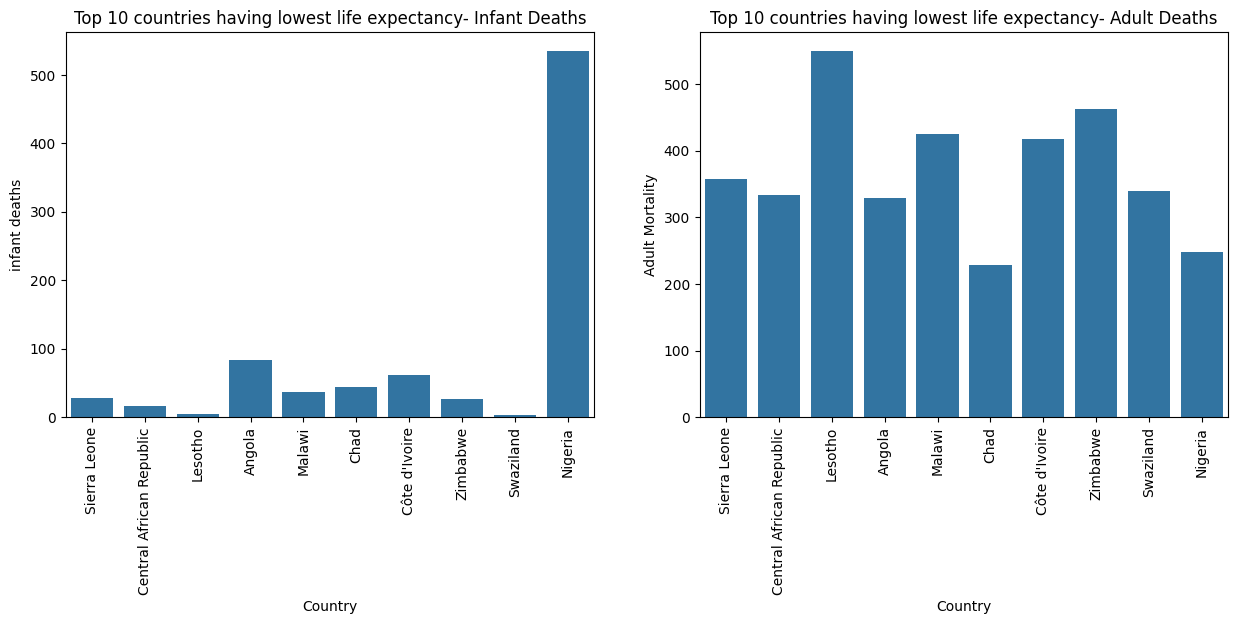

In [17]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
infant = sns.barplot(data = low_life, x = low_life.Country, y = low_life['infant deaths'])
infant.set_title("Top 10 countries having lowest life expectancy- Infant Deaths")
infant.set_xticklabels(infant.get_xticklabels(), rotation = 90)

plt.subplot(1,2,2)
adult = sns.barplot(data = low_life, x = low_life.Country, y = low_life['Adult Mortality'])
adult.set_title("Top 10 countries having lowest life expectancy- Adult Deaths")
adult.set_xticklabels(adult.get_xticklabels(), rotation = 90)


plt.show()


From the bar plots above and by taking the mean, we can infer that the average Life Expectancy is more for the countries that have many years of schooling as compared to those that have very few schooling years

**Dropping unwanted columns**
We drop the column 'Country' as it will no longer be needed for running the models. There are too many country names, hence high cardinality and we cannot create one hot vector for this colum

In [18]:
df.drop('Country', axis = 1, inplace = True)

Correlation analysis

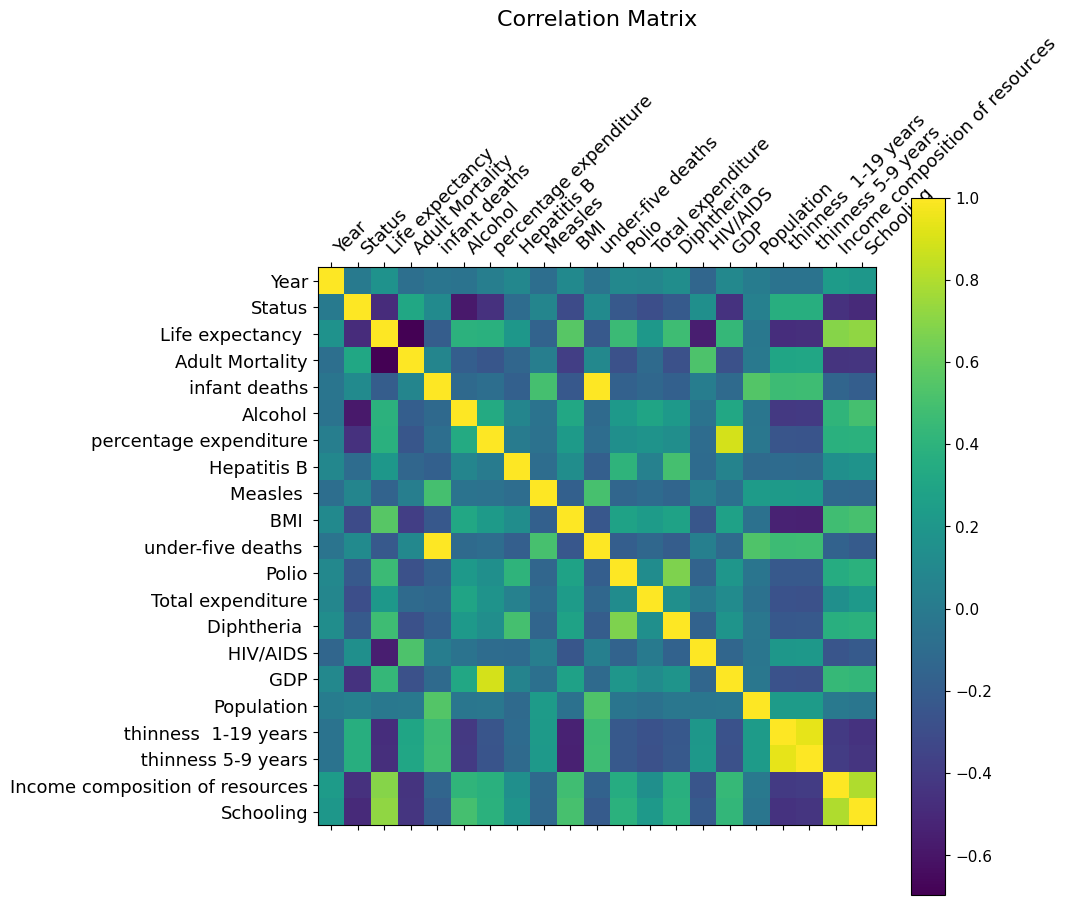

In [19]:
f = plt.figure(figsize=(9, 9))
plt.matshow(df.corr(), fignum=f.number)
plt.xticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=13, ha="left", rotation=45)
plt.yticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=13)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=11)
plt.title('Correlation Matrix', fontsize=16);

The following features are highly correlated:

Under 5 deaths <---> Infant Deaths. Hence we will remove the feature under 5 deaths
Thinness 5-9 <---> Thinness 1-19. Hence we will remove the heature Thinness 5-9

In [20]:
df.drop(columns=['under-five deaths ',' thinness  1-19 years'],axis =1, inplace=True)

Split and Train the data 

In [21]:
X = df.drop('Life expectancy ', axis=1)
y = df['Life expectancy ']

We are using the MinMax Scaler for our dataset to bring all values within the range 0-1. The dataset is not sparse and has a good amount of continuous columns. However, some columns have values in thousands, some in hundreds and some 0 and 1. The featureset is comprised of different scales of continuous valued colums. As explained for the Boston Housing data which has a similar structre, we have used MinMax scaler

In [22]:
# Columns to scale
cols_to_scale = [ 'Year', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
        ' thinness 5-9 years',
       'Income composition of resources', 'Schooling']

# Apply Min-Max scaling to the specified columns
scaler = MinMaxScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

In [23]:
X

,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 5-9 years,Income composition of resources,Schooling
0,1.000000,1,0.362881,0.034444,0.000000,0.003659,0.653061,0.005439,0.209733,0.031250,0.452118,0.649485,0.000000,0.004889,0.026074,0.603509,0.505274,0.487923
1,0.933333,1,0.373961,0.035556,0.000000,0.003774,0.622449,0.002319,0.203940,0.572917,0.453279,0.618557,0.000000,0.005127,0.000253,0.610526,0.502110,0.483092
2,0.866667,1,0.369806,0.036667,0.000000,0.003759,0.642857,0.002027,0.198146,0.614583,0.450377,0.639175,0.000000,0.005287,0.024525,0.617544,0.495781,0.478261
3,0.800000,1,0.375346,0.038333,0.000000,0.004014,0.673469,0.013135,0.192352,0.666667,0.473012,0.670103,0.000000,0.005608,0.002857,0.628070,0.488397,0.473430
4,0.733333,1,0.379501,0.039444,0.000000,0.000364,0.683673,0.014200,0.187717,0.677083,0.435287,0.680412,0.000000,0.000519,0.002302,0.635088,0.478903,0.458937
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,0.266667,1,1.000000,0.015000,0.243561,0.000000,0.683673,0.000146,0.302433,0.666667,0.392339,0.649485,0.663366,0.003799,0.009875,0.326316,0.429325,0.444444
2934,0.200000,1,0.988920,0.014444,0.226764,0.000000,0.061224,0.004703,0.297798,0.041667,0.356936,0.680412,0.724752,0.003790,0.009764,0.343860,0.440928,0.458937
2935,0.133333,1,0.099723,0.013889,0.247480,0.000000,0.734694,0.001433,0.293163,0.729167,0.357516,0.711340,0.786139,0.000467,0.000097,0.042105,0.450422,0.483092
2936,0.066667,1,0.948753,0.013889,0.095745,0.000000,0.765306,0.002493,0.288528,0.760417,0.336042,0.752577,0.831683,0.004589,0.009558,0.056140,0.450422,0.473430


Train/Test split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:

print("X_train shape: ",X_train.shape)
print("y_train shape: ",y_train.shape)
print("X_test shape: ",X_test.shape)
print("y_test shape",y_test.shape)


X_train shape:  (2350, 18)
y_train shape:  (2350,)
X_test shape:  (588, 18)
y_test shape (588,)


# MODELS and MODELS EVALUATION

## Régression Linéaire

In [26]:
from sklearn.linear_model import LinearRegression
#To find the hyperparameter list of a model
lreg = LinearRegression()
lreg_params = lreg.get_params()
print(f'Default Linear Reg hyperparameters: {lreg_params}')

Default Linear Reg hyperparameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}


In [27]:
param_grid_lin = {'copy_X': [True,False], 'fit_intercept': [True,False]}
print("Parameter grid:\n{}".format(param_grid_lin))

from sklearn.model_selection import GridSearchCV
grid_search_lin = GridSearchCV(estimator=lreg, param_grid=param_grid_lin, return_train_score=True, n_jobs=None, cv=7)
grid_search_lin.fit(X_train, y_train)

print("Best parameters: {}".format(grid_search_lin.best_params_))

Parameter grid:
{'copy_X': [True, False], 'fit_intercept': [True, False]}
Best parameters: {'copy_X': True, 'fit_intercept': True}


We have found the train and test scores for the linear regression model. Let's also find the R2 score and MSE when you use the LReg model on the dataset

In [28]:
ylinear_predicted= grid_search_lin.predict(X_test)

We're plotting the number of schooling years across the life expectancy. There is clearly a linear upward trend i.e more the number of years of schooling, higher will be the average life expectancy. We have fit a linear model represented by the red line

Text(0, 0.5, 'Life Expectancy')

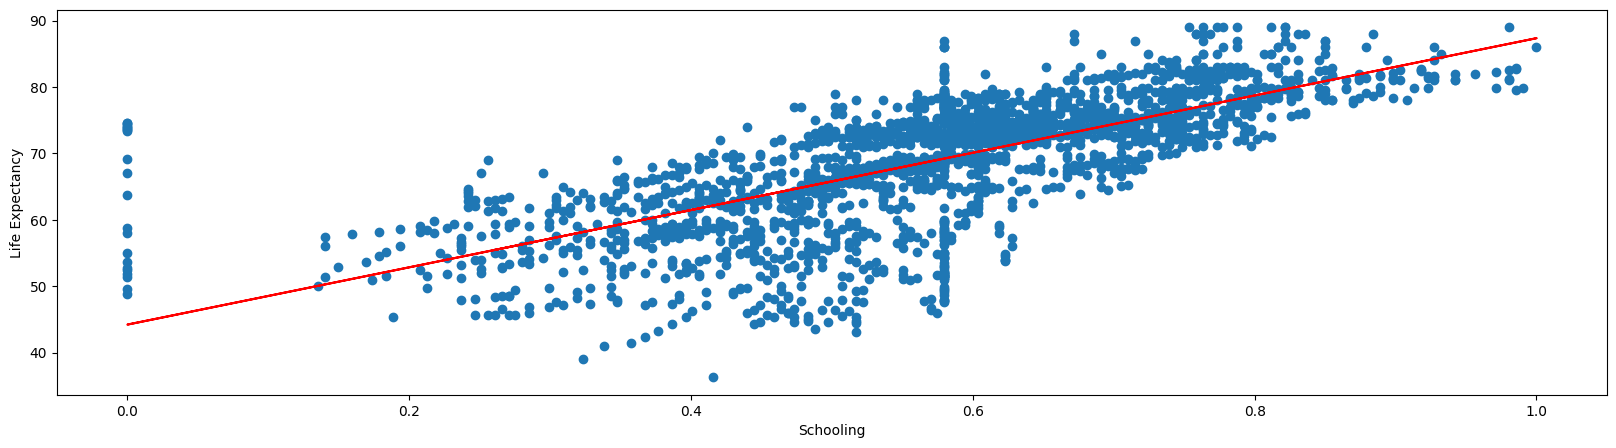

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt

 
X_train_school = X_train[['Schooling']]
grid_search_lin.fit(X_train_school, y_train)
y_predict_lifexp = grid_search_lin.predict(X_train_school)

plt.subplots(figsize = (20,5))
plt.plot(X_train_school, y_predict_lifexp, c = 'r')
plt.scatter(X_train_school,y_train)
plt.xlabel('Schooling')
plt.ylabel('Life Expectancy')

In [30]:
print(X_train.columns)


Index(['Year', 'Status', 'Adult Mortality', 'infant deaths', 'Alcohol',
       'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'Polio',
       'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')


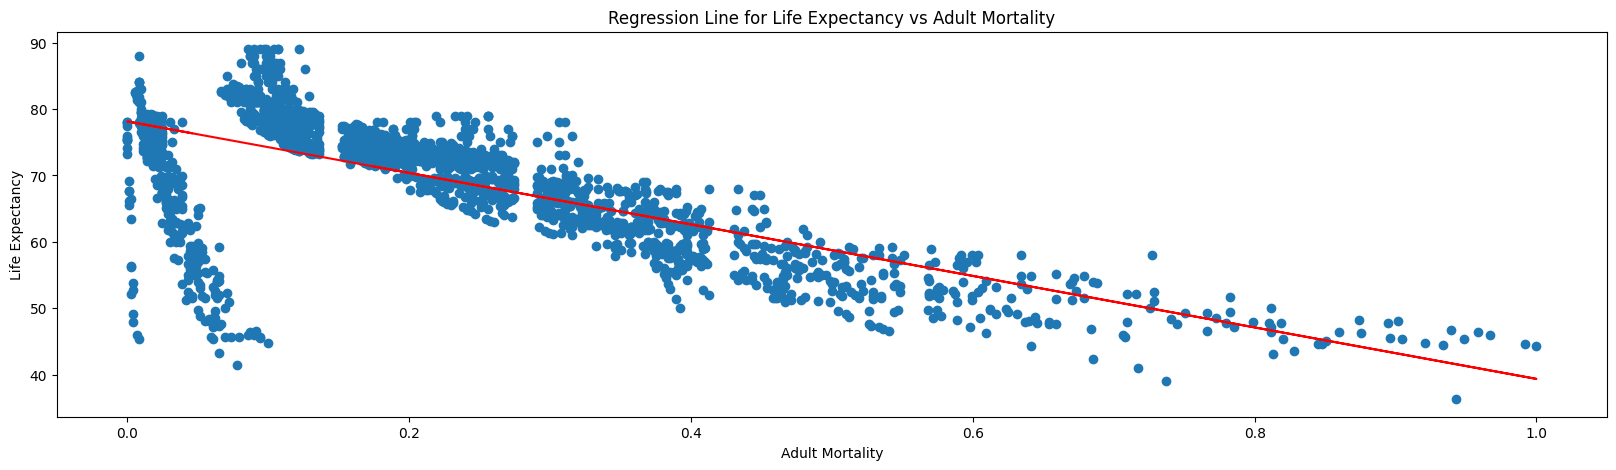

In [31]:
X_train_income = X_train[['Adult Mortality']]  # Replace 'Income' with any other feature
grid_search_lin.fit(X_train_income, y_train)

# Predict life expectancy using the new feature
y_predict_lifexp = grid_search_lin.predict(X_train_income)

# Plotting the data and regression line
plt.subplots(figsize=(20, 5))
plt.plot(X_train_income, y_predict_lifexp, c='r')  # Plot regression line
plt.scatter(X_train_income, y_train)  # Scatter plot for the actual data points
plt.xlabel('Adult Mortality')  # Change label to match the new feature
plt.ylabel('Life Expectancy')
plt.title('Regression Line for Life Expectancy vs Adult Mortality')
plt.show()



Les modèles de régression pour 'Schooling' et 'Adult Mortality' ont donné de bons résultats, montrant une forte coleration avec la variable cible.

**Using Grid Search to find the best hyperparameters**

The above are the best parameters for the Simple Linear Regression Model. Let's apply these hyperparameters to the training and test datasets to find the R2 score, MSE

In [34]:
from sklearn import metrics
grid_search_lin.fit(X_train, y_train)
ylinear_predicted = grid_search_lin.predict(X_test)

print('MSE:', metrics.mean_squared_error(y_test,ylinear_predicted))
print('R2_score: {:.4f}'.format(metrics.r2_score(y_test,ylinear_predicted)))

MSE: 16.34121183261647
R2_score: 0.8114


Un MSE de 16.34 cest un peu elevee ,cest a cause de la complexite du dataset.
Un R² de 0.8114 montre que votre modèle explique 81.14% de la variance, ce qui est assez élevé et indique un bon resultat.

We can see that there is not much change in the scores and errors using default parameters and with using best parameters

## Régression Polynomiale

In [35]:
from  sklearn.preprocessing  import PolynomialFeatures
train_score_list_poly = []
test_score_list_poly = []

for i in range(1,4):
    poly = PolynomialFeatures(i)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_train)
    train_score_list_poly.append(poly_reg.score(X_train_poly, y_train))
    test_score_list_poly.append(poly_reg.score(X_test_poly, y_test)) 

In [36]:
print(train_score_list_poly)
print(test_score_list_poly)

[0.8097323196326233, 0.9247805563532331, 0.9845713663794521]
[0.8113792393128688, 0.9157351680355692, -161.06016924678616]


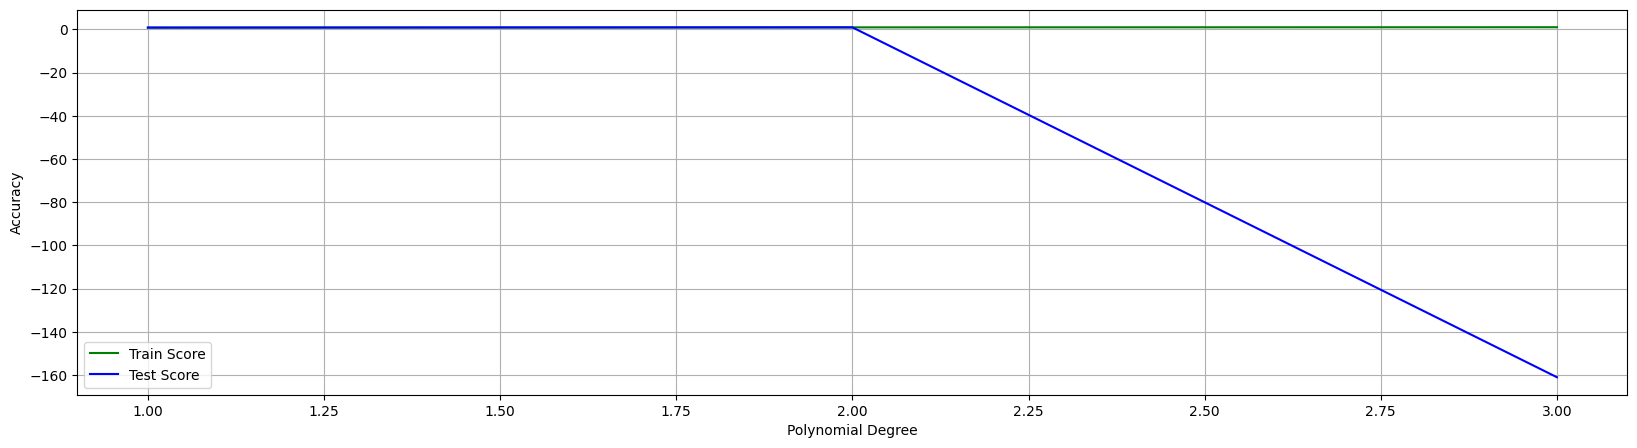

In [37]:
#Visualizing values of the hyperparamters i.e polynomial degree for Polynomial Features model to see which could be best
%matplotlib inline
import matplotlib.pyplot as plt

plt.subplots(figsize = (20,5))
plt.plot(range(1,4), train_score_list_poly, c = 'g', label = 'Train Score')
plt.plot(range(1,4), test_score_list_poly, c = 'b', label = 'Test Score')
plt.legend(loc = 3)
plt.xlabel('Polynomial Degree')
plt.ylabel('Accuracy')
plt.grid()

accuracy de train et de test sont élevés pour les polynômes de degré 1 et 2, indiquant une bonne généralisation, mais la performance se dégrade au-delà du degré 2, suggérant un overfitting(veut dire que le modele avec un polynome complexe apprendre tous les details de train set).


The train and test scores are high for polynomial of degrees 1 and 2. Test score starts deteriorating after 2

Let's plot Polynomail Feature(2) model on 2 features - y axis Life Expectancy and x-axis Schooling. We should see a curve as model

Text(0, 0.5, 'Life Expectancy')

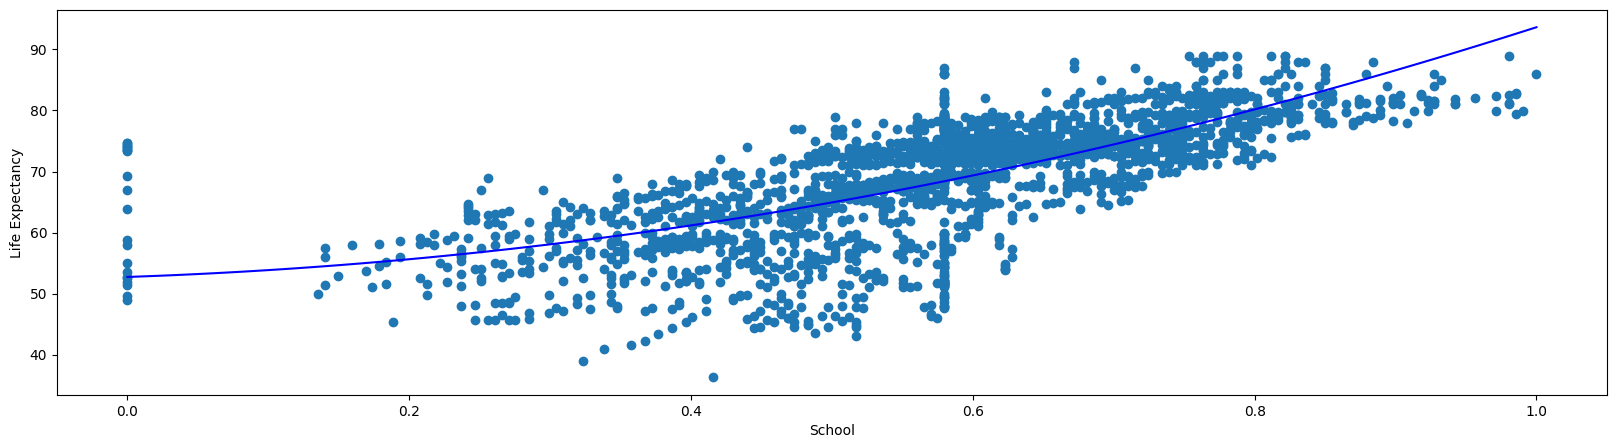

In [38]:

%matplotlib inline
import matplotlib.pyplot as plt

X_train_school = X_train.iloc[:, 17].values.reshape(-1, 1)
poly = PolynomialFeatures(2)
school_Xtrain_poly = poly.fit_transform(X_train_school)
lreg.fit(school_Xtrain_poly, y_train)

x_axis = np.linspace(0,1,100).reshape(-1,1)
x_poly = poly.transform(x_axis)
y_predict_lifexp = lreg.predict(x_poly)


plt.subplots(figsize = (20,5))
plt.plot(x_axis, y_predict_lifexp, c = 'b')
plt.scatter(X_train_school,y_train)
plt.xlabel('School')
plt.ylabel('Life Expectancy')

In [39]:
poly = PolynomialFeatures(2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
poly_reg.fit(X_train_poly, y_train)

y_poly_predicted = poly_reg.predict(X_test_poly)

print('Train score: {:.4f}'.format(poly_reg.score(X_train_poly, y_train)))
print('Test score: {:.4f}'.format(poly_reg.score(X_test_poly, y_test)))

print('R2_score: {:.4f}'.format(r2_score(y_test,y_poly_predicted)))
MSE = np.square(np.subtract(y_test,y_poly_predicted)).mean()
print('MSE: {:.4f}'.format(MSE))

Train score: 0.9248
Test score: 0.9157
R2_score: 0.9157
MSE: 7.3003


Le modèle de régression polynomiale atteint un R² de 0.9157 et un MSE de 7.30, ce qui montre une amélioration significative des performances par rapport au modèle linéaire


Using grid search to find the best hyperparameters for polynomial regression

In [40]:
#We have used Naive Grid Search to find the best hyperparams
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score 
degrees = [2, 3, 4] # Change degree "hyperparameter" here
normalizes = [True, False] # Change normalize hyperparameter here
best_score = 0
best_degree = 0
for degree in degrees:
    for normalize in normalizes:
        poly_features = PolynomialFeatures(degree = degree)
        X_train_poly = poly_features.fit_transform(X_train)
        polynomial_regressor = LinearRegression()
        polynomial_regressor.fit(X_train_poly, y_train)
        scores = cross_val_score(polynomial_regressor, X_train_poly, y_train, cv=5) # Change k-fold cv value here
        if max(scores) > best_score:
            best_score = max(scores)
            best_degree = degree
            best_normalize = normalize

(best_degree)

2

In [41]:
best_score

np.float64(0.9097691221557601)

In [42]:

best_normalize

True

In [43]:


best_poly_reg = PolynomialFeatures(degree=2)
X_train_poly = best_poly_reg.fit_transform(X_train)
X_test_poly = best_poly_reg.transform(X_test)
lreg_poly=LinearRegression(copy_X= True, fit_intercept=True)
lreg_poly.fit(X_train_poly, y_train)

y_pred_poly=lreg_poly.predict(X_test_poly)

print('Train score: {:.4f}'.format(lreg_poly.score(X_train_poly, y_train)))
print('Test score: {:.4f}'.format(lreg_poly.score(X_test_poly, y_test)))


print('R2_score: {:.4f}'.format(r2_score(y_test,y_pred_poly)))
MSE = np.square(np.subtract(y_test,y_pred_poly)).mean()
print('MSE: {:.4f}'.format(MSE))

Train score: 0.9248
Test score: 0.9157
R2_score: 0.9157
MSE: 7.3003


In [44]:
train_cvscore_poly = cross_val_score(polynomial_regressor, X_train, y_train, cv=7)
print(train_cvscore_poly)

#Average Cross Validation Score for Train Set
print("The average cross validated train score is: {:.4f}".format(train_cvscore_poly.mean()))

[0.81205661 0.83367094 0.79996031 0.78377722 0.78086582 0.79538349
 0.81173218]
The average cross validated train score is: 0.8025


## Réseau de Neurones Artificiel

In [45]:
model = Sequential([
        Dense(64, activation='relu', input_dim=18),
        Dense(64, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='linear')
])

In [46]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error','mean_squared_error'])

In [47]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,601 (37.50 KB)

 Trainable params: 9,601 (37.50 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [49]:
history = model.fit(X_train, y_train, epochs=150, validation_split=0.2)

Epoch 1/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 4553.7891 - mean_absolute_error: 66.6654 - mean_squared_error: 4553.7891 - val_loss: 1152.6716 - val_mean_absolute_error: 32.8193 - val_mean_squared_error: 1152.6716
Epoch 2/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 370.5420 - mean_absolute_error: 15.6479 - mean_squared_error: 370.5420 - val_loss: 81.6812 - val_mean_absolute_error: 7.2420 - val_mean_squared_error: 81.6812
Epoch 3/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 74.6626 - mean_absolute_error: 6.7567 - mean_squared_error: 74.6626 - val_loss: 61.7143 - val_mean_absolute_error: 6.2190 - val_mean_squared_error: 61.7143
Epoch 4/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 54.5403 - mean_absolute_error: 5.7428 - mean_squared_error: 54.5403 - val_loss: 45.7724 - val_mean_absolute_error: 5.2508 - val_mean_squared_error: 45.7724
Epoch 5/150
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 42.2355 - mean_absolute_error: 5.0165 - mean_squared_error: 42.2355

In [50]:
y_predann = model.predict(X_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [51]:
from sklearn.metrics import r2_score, mean_squared_error

R2 = r2_score(y_test, y_predann)
MSE = mean_squared_error(y_test, y_predann)

print("R2 Score =", R2)
print("MSE =", MSE)


R2 Score = 0.9221372753818469
MSE = 6.745658708059319


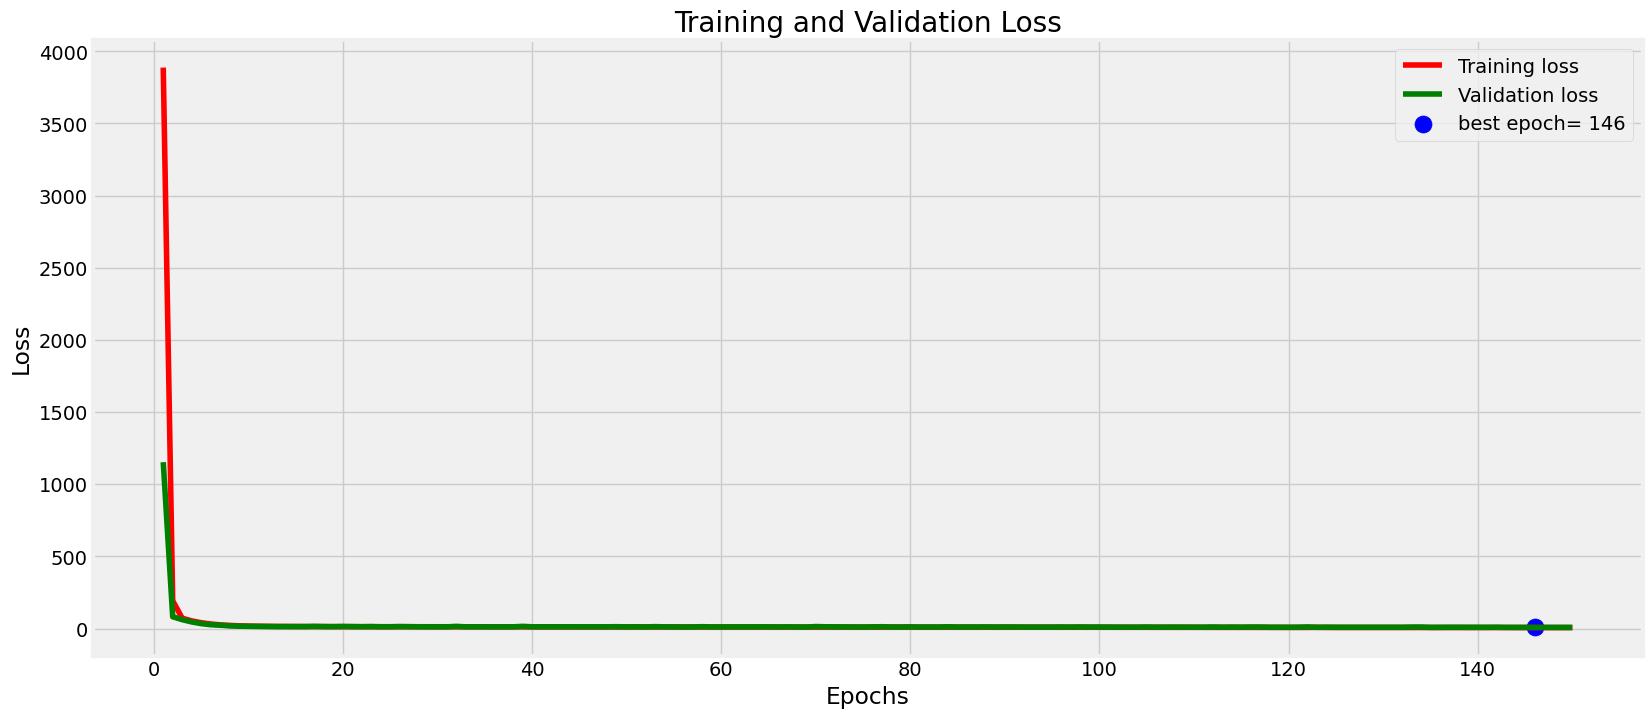

In [52]:
# Define needed variables
tr_loss = history.history['loss']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

Epochs = [i+1 for i in range(len(tr_loss))]
loss_label = f'best epoch= {str(index_loss + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', 
            label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout
plt.show()

Le graphe représentant l’évolution de la perte d’entraînement et de validation du réseau

de neurones montre une diminution rapide de l’erreur au début, suivie d’une stabilisation in-
diquant une bonne convergence du modèle.

## Gradient Boosting Regressor

In [53]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Define the model
gbr = GradientBoostingRegressor()

# 2. Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

# 3. Set up GridSearchCV
grid_search = GridSearchCV(estimator=gbr,
                           param_grid=param_grid,
                           cv=5,             # 5-fold cross-validation
                           scoring='r2',     # or 'neg_mean_squared_error'
                           n_jobs=-1,
                           verbose=2)

# 4. Fit the model
grid_search.fit(X_train, y_train)

# 5. Best model and parameters
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [54]:
predictionsGB = best_model.predict(X_test)

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Mean Absolute Error
mae = mean_absolute_error(y_test, predictionsGB)
print(f'Mean Absolute Error (MAE): {mae}')

# Mean Squared Error
mse = mean_squared_error(y_test, predictionsGB)
print(f'Mean Squared Error (MSE): {mse}')

# Root Mean Squared Error
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')

# R² Score
r2 = r2_score(y_test, predictionsGB)
print(f'R² Score: {r2}')

Mean Absolute Error (MAE): 1.134969134415261
Mean Squared Error (MSE): 2.85582099578736
Root Mean Squared Error (RMSE): 1.6899174523589489
R² Score: 0.9670362801651874


 Le Gradient Boosting Regressor atteint un R² de 0.9682 avec un MAE de 1.11 , ce qui indique une excellente précision prédictive et une très bonne généralisation. 

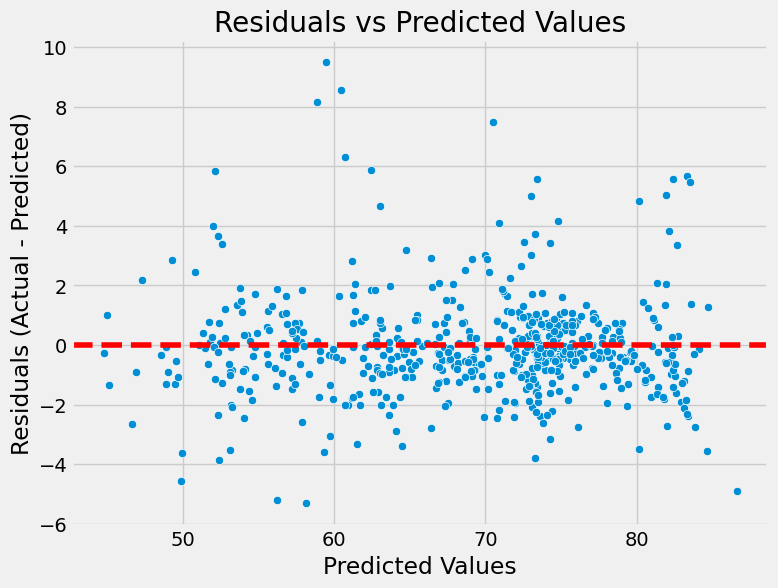

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have these:
# y_test : true values
# y_pred : predicted values by your Gradient Boosting model

# Calculate residuals
residuals = y_test - predictionsGB

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=predictionsGB, y=residuals)
plt.axhline(0, color='red', linestyle='--')  # horizontal line at 0
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted Values')
plt.show()

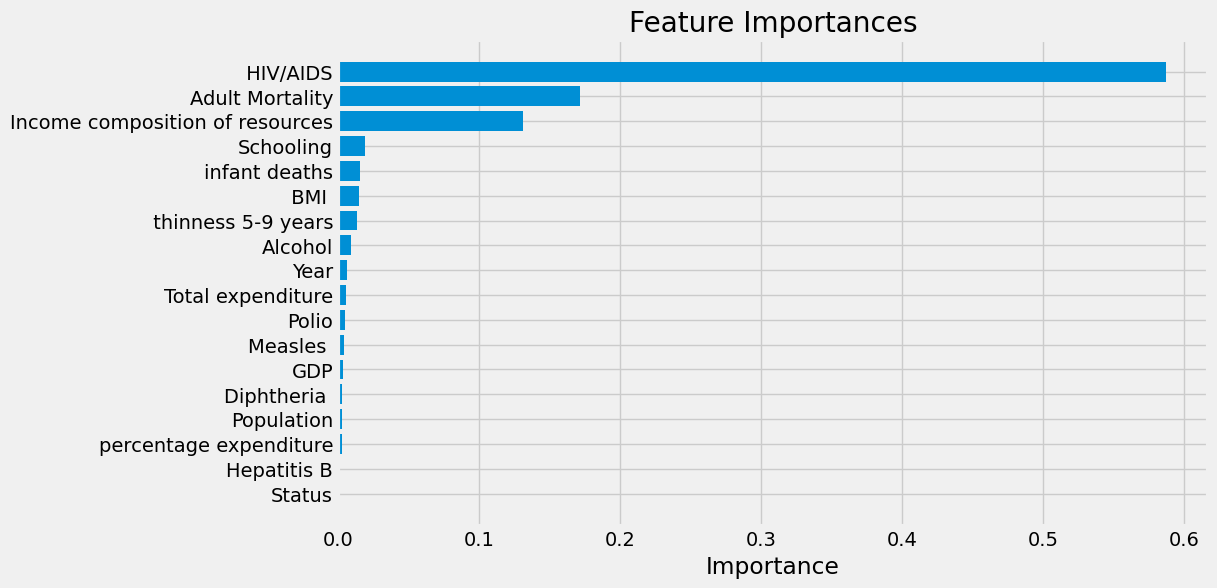

In [57]:
import numpy as np

# Assuming 'model' is your trained GradientBoostingRegressor
feature_importances = best_model.feature_importances_
features = X_train.columns  # if your input is a DataFrame

# Sort features by importance
indices = np.argsort(feature_importances)

plt.figure(figsize=(10,6))
plt.barh(features[indices], feature_importances[indices])
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.show()

 La variable HIV/AIDS a une grande importance dans le modèle car elle reflète une cause majeure de mortalité qui affecte fortement l’espérance de vie, surtout dans certaines régions où cette maladie est plus répandue. 

La variable Income composition of resources est aussi très importante car elle reflète la richesse et les ressources disponibles dans un pays, ce qui influence la santé et l’espérance de vie. 

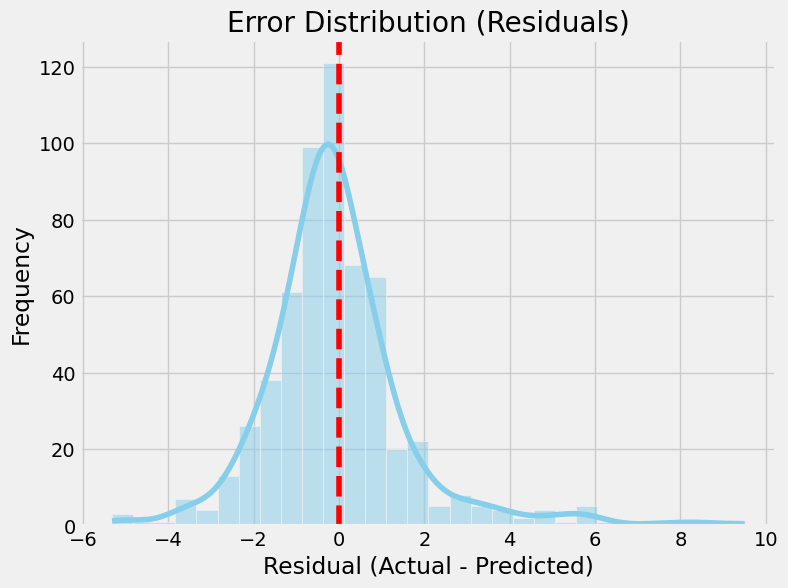

In [58]:
# Assuming you already have:
# y_test : true target values
# y_pred : predicted target values

# Step 1: Calculate residuals
residuals = y_test - predictionsGB

# Step 2: Plot
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30, color='skyblue')
plt.axvline(0, color='red', linestyle='--')  # Line at 0 error
plt.title('Error Distribution (Residuals)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Normalize features for better convergence
X_norm = (X - X.mean()) / X.std()
X_norm.insert(0, 'Intercept', 1)  # Add bias term
X_matrix = X_norm.values
y_vector = y.values.reshape(-1, 1)

# Initialize parameters
theta = np.zeros((X_matrix.shape[1], 1))
alpha = 0.01
iterations = 1000
m = len(y_vector)

# Cost function history
cost_history = []

# Gradient descent loop
for i in range(iterations):
    predictions = X_matrix @ theta
    errors = predictions - y_vector
    cost = (1/(2*m)) * np.sum(errors**2)
    cost_history.append(cost)
    gradients = (1/m) * X_matrix.T @ errors
    theta -= alpha * gradients

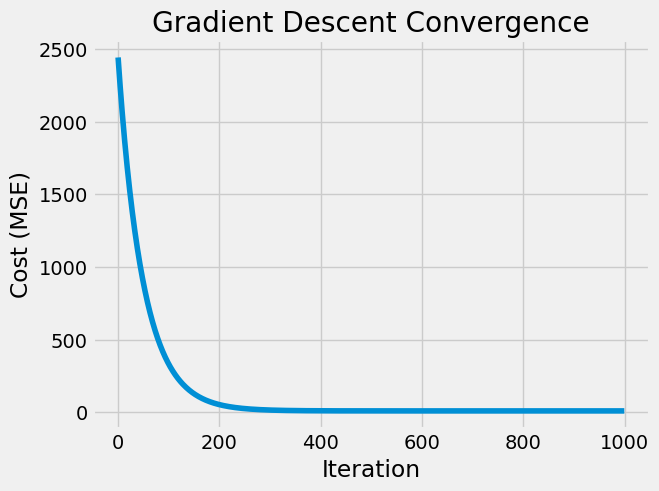

In [60]:
plt.plot(range(iterations), cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.title("Gradient Descent Convergence")
plt.grid(True)
plt.show()

## Régression par Arbre de Décision

In [61]:
np.where(X.columns == 'Schooling')

(array([17]),)

Text(0.5, 0, 'Schooling')

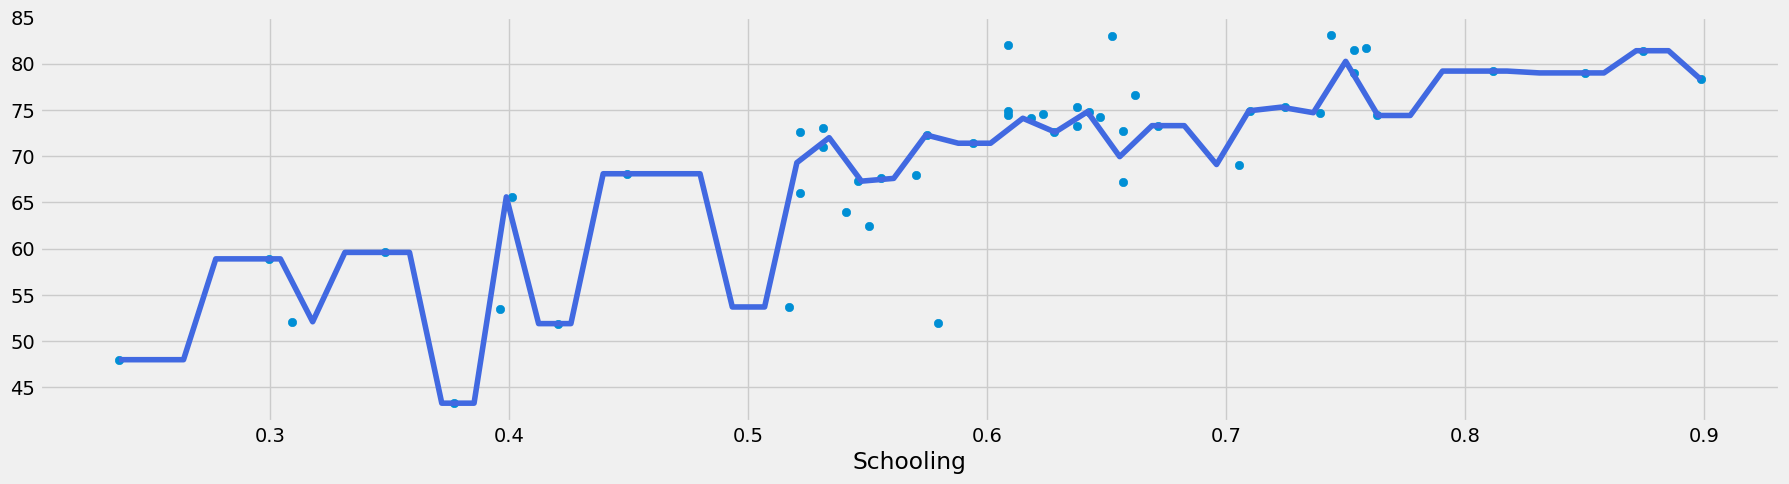

In [62]:
from sklearn.tree import DecisionTreeRegressor

X_b = X_train[['Schooling']].iloc[:50]
y_b = y_train[:50]

clf = DecisionTreeRegressor()
clf.fit(X_b, y_b)

X_new=np.linspace(X_b.min(), X_b.max(), 50).reshape(50, 1)
y_predict = clf.predict(X_new)

plt.subplots(figsize = (20,5))
plt.plot(X_new, y_predict, c = 'royalblue')
plt.scatter(X_b, y_b)
plt.xlabel('Schooling')

In [63]:
from sklearn.tree import DecisionTreeRegressor

dt_train_score=[]
dt_test_score=[]

for i in range(1,15):
    dtregressor = DecisionTreeRegressor(max_depth=i,random_state= 0)
    dtregressor.fit(X_train, y_train)
    dt_train_score.append(dtregressor.score(X_train, y_train))
    dt_test_score.append(dtregressor.score(X_test, y_test))

In [64]:
print(dt_train_score)
print(dt_test_score)

[0.5770359504010478, 0.7286648244658264, 0.8260881356553011, 0.876293831899475, 0.9127516679187989, 0.9338144062615307, 0.9524666997373084, 0.9665512035208228, 0.9768730744887094, 0.9849782580020972, 0.990393820002527, 0.9941784866122201, 0.9965695001118088, 0.9978683842265418]
[0.5762473513686819, 0.7209191750939501, 0.8123274956888051, 0.8674253612319944, 0.8985197025574916, 0.9182013463352676, 0.9288454762888634, 0.9254213763785053, 0.9307770234497998, 0.9285022825665494, 0.9337705619262903, 0.92631242783306, 0.9266546893919364, 0.9269029200688328]


Text(0, 0.5, 'Accuracy')

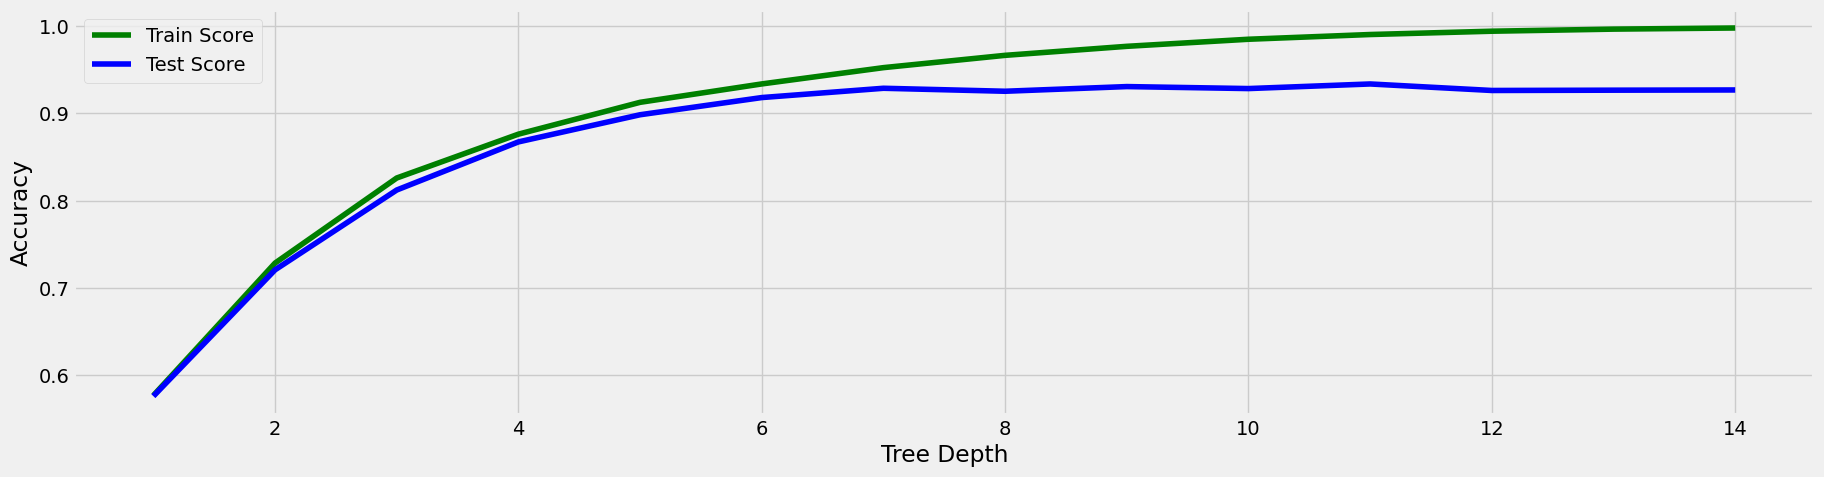

In [65]:
x_axis = range(1,15)
plt.subplots(figsize = (20,5))
plt.plot(x_axis, dt_train_score, c = 'g', label = 'Train Score')
plt.plot(x_axis, dt_test_score, c = 'b', label = 'Test Score')
plt.legend()
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')

Just visualizing, the best hyperparameter depth seems to be 6 because it has high train and test scores and a small gap between train and test scores

In [66]:
dtregressor = DecisionTreeRegressor(max_depth=6)
dtregressor.fit(X_train, y_train)
ydt_predicted = dtregressor.predict(X_test)

print('Train score: {:.4f}'.format(dtregressor.score(X_train, y_train)))
print('Test score: {:.4f}'.format(dtregressor.score(X_test, y_test)))
print('R2_score: {:.4f}'.format(r2_score(y_test,ydt_predicted)))
MSE = np.square(np.subtract(y_test,ydt_predicted)).mean()
print('MSE: {:.4f}'.format(MSE))

Train score: 0.9338
Test score: 0.9170
R2_score: 0.9170
MSE: 7.1941


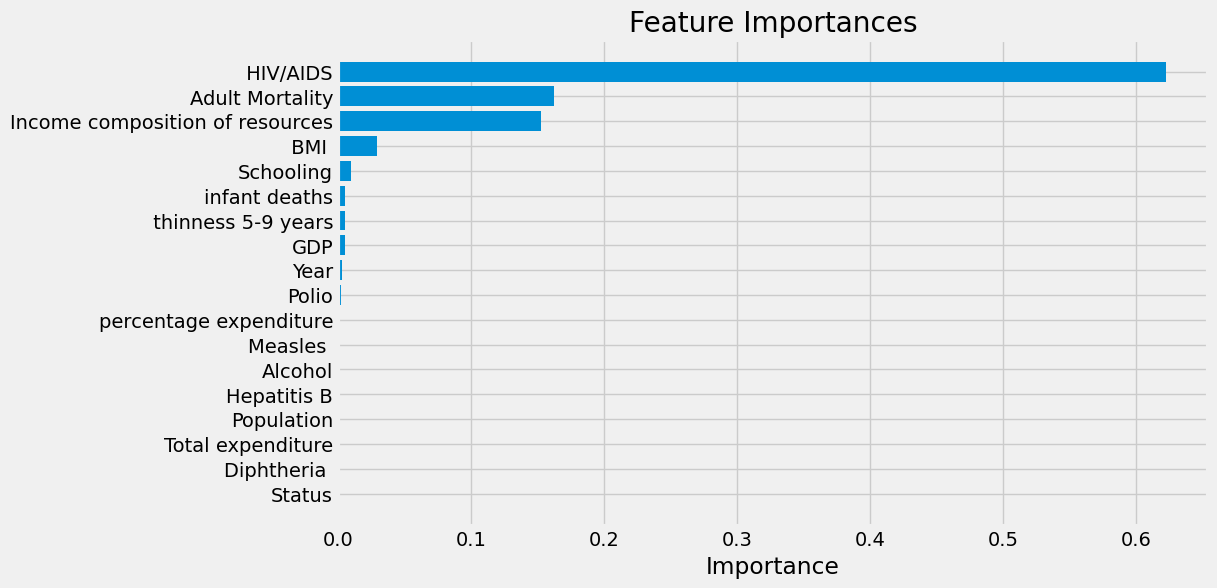

In [67]:
feature_importances = dtregressor.feature_importances_
features = X_train.columns  # if your input is a DataFrame

# Sort features by importance
indices = np.argsort(feature_importances)

plt.figure(figsize=(10,6))
plt.barh(features[indices], feature_importances[indices])
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.show()

In [68]:
print(features)
print(feature_importances)

Index(['Year', 'Status', 'Adult Mortality', 'infant deaths', 'Alcohol',
       'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'Polio',
       'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')
[3.28465484e-03 0.00000000e+00 1.62571397e-01 5.23601991e-03
 2.65223509e-04 1.90674834e-03 1.72013349e-04 3.18102749e-04
 2.90396789e-02 2.04304561e-03 0.00000000e+00 0.00000000e+00
 6.22532436e-01 5.13353096e-03 6.15711008e-05 5.21257263e-03
 1.52529803e-01 9.69320147e-03]


## Other Models Implemented for better exploration the data 


 ## KNN Regressor
 
KNN regressor is used to find the number of neighbours which with help us determine the y_predicted (predicted life expectancy) value for an instance in the dataset. The chosen n should maximize the train and test scores, have a small difference bwteen them, have a good R2 score and minimize the MSE.

  File "C:\Users\BIG BOX\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Text(0, 0.5, 'Accuracy')

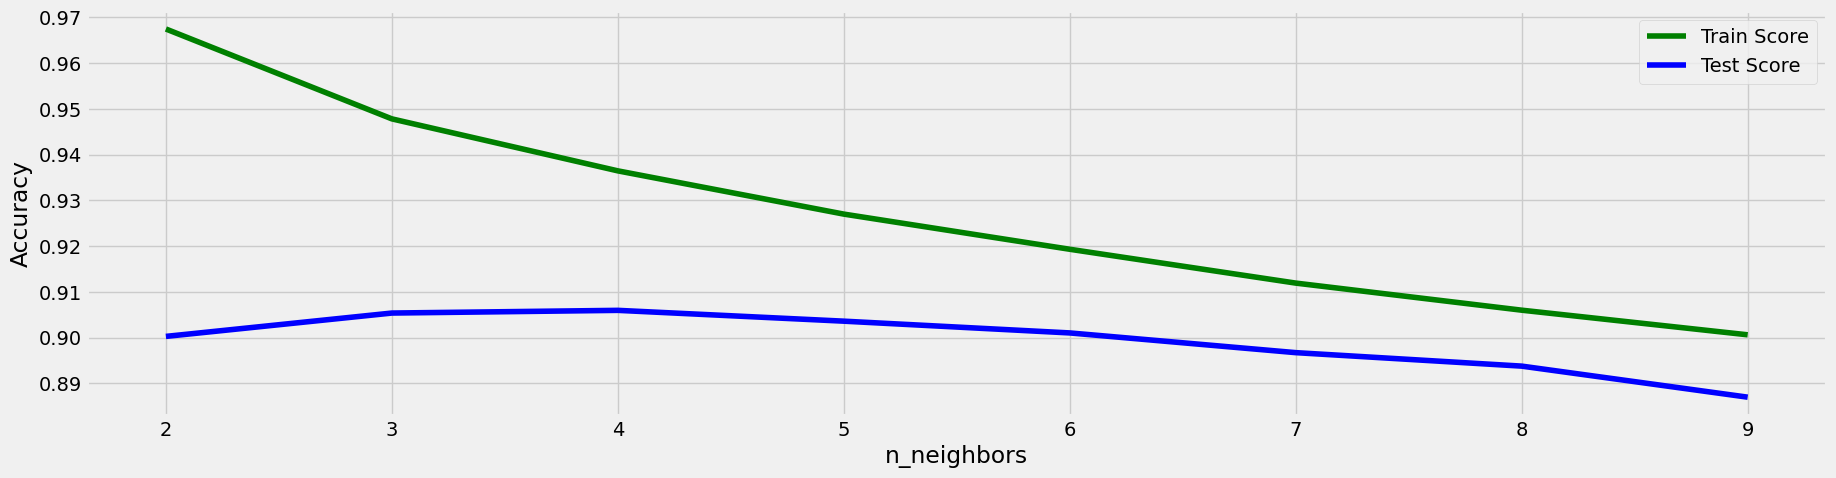

In [69]:
from sklearn.neighbors import KNeighborsRegressor
%matplotlib inline
train_score_array = []
test_score_array = []

for k in range(2,10):
    knn_reg = KNeighborsRegressor(k)
    knn_reg.fit(X_train, y_train)
    train_score_array.append(knn_reg.score(X_train, y_train))
    test_score_array.append(knn_reg.score(X_test, y_test))

x_axis = range(2,10)
plt.subplots(figsize = (20,5))
plt.plot(x_axis, train_score_array, c = 'g', label = 'Train Score')
plt.plot(x_axis, test_score_array, c = 'b', label = 'Test Score')
plt.legend()
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')


We can see that the train and test score is relatively high when the n_neighbours is 3. Also considering that the difference between the train and test score is lower compared to other values of k

In [70]:
train_score_np = np.array(train_score_array)
test_score_np = np.array(test_score_array)
print('Train score',train_score_array)
print('Test score',test_score_array)
difference = train_score_np - test_score_np
print('Difference',difference)

Train score [0.9674210689040312, 0.9477882126921731, 0.9364317019256942, 0.9269857979407344, 0.919305269087133, 0.9119147704275478, 0.9059976013698383, 0.9006185927432726]
Test score [0.9002713759813645, 0.905371481060302, 0.9059612624703093, 0.903598541119167, 0.9010286991996567, 0.8967232004816242, 0.8937786276426208, 0.8869960122570637]
Difference [0.06714969 0.04241673 0.03047044 0.02338726 0.01827657 0.01519157
 0.01221897 0.01362258]



**Selecting number of neighbours=3 randomly**

In [71]:
knn_reg = KNeighborsRegressor(3)
knn_reg.fit(X_train, y_train)
y_predicted = knn_reg.predict(X_test)

print("train score: {:.4f}".format(knn_reg.score(X_train, y_train)))
print("test score: {:.4f}".format(knn_reg.score(X_test, y_test)))
print('difference: {:.4f}'.format((knn_reg.score(X_train, y_train)) - (knn_reg.score(X_test, y_test))))

train score: 0.9478
test score: 0.9054
difference: 0.0424



We can also use the GridSearchCV to find the best hyperparameters(in KNN case k or number of nearest neighbours) for the model

In [72]:
param_grid_knn = {'n_neighbors':range(2,10), 'weights':['distance','uniform'],'p': [1,2]}
print("Parameter grid:\n{}".format(param_grid_knn))

from sklearn.model_selection import GridSearchCV
grid_search_knn = GridSearchCV(estimator=knn_reg, param_grid=param_grid_knn, return_train_score=True, cv=7)
grid_search_knn.fit(X_train, y_train)

print("Best parameters: {}".format(grid_search_knn.best_params_))

Parameter grid:
{'n_neighbors': range(2, 10), 'weights': ['distance', 'uniform'], 'p': [1, 2]}
Best parameters: {'n_neighbors': 4, 'p': 1, 'weights': 'distance'}


Using the Grid Search CV, we have got best parameters as k=3 and weights=distance. For regression, the cost function is the MSE and the metric to check the best fit of the model is R2 score

In [73]:
from sklearn import metrics
#from sklearn.metrics import mean_squared_error
knn_reg_best = KNeighborsRegressor(n_neighbors =3 , weights = 'distance', p=1)
knn_reg_best.fit(X_train, y_train)
y_predicted = knn_reg_best.predict(X_test)

print('Train score: {:.4f}'.format(knn_reg_best.score(X_train, y_train)))
print('Test score: {:.4f}'.format(knn_reg_best.score(X_test, y_test)))
print("R2_score: {:.4f} ".format(metrics.r2_score(y_test,y_predicted)))
MSE = np.square(np.subtract(y_test,y_predicted)).mean()
print('MSE: {:.4f}'.format(MSE))

#There seems to be some data leakage as the train score is a perfect 1. Hence, although this has high scores and low MSE, we won't consider this as the best model

Train score: 1.0000
Test score: 0.9405
R2_score: 0.9405 
MSE: 5.1506


**Finding the average Training and Testing Score using Cross Validation**

In [74]:
from sklearn.model_selection import cross_val_score

train_cvscore = cross_val_score(knn_reg_best, X_train, y_train, cv=7)
print(train_cvscore)

#Average Cross Validation Score for Train Set
print("The average cross validated train score is: {:.4f}".format(train_cvscore.mean()))

[0.93229004 0.93526757 0.92436314 0.94095672 0.92442786 0.92127873
 0.93095837]
The average cross validated train score is: 0.9299


In [75]:
test_cvscore = cross_val_score(knn_reg, X_test, y_test, cv=7)
print(test_cvscore)

#Average Cross Validation Score for Train Set
print("The average cross validated test score is: {:.4f}".format(test_cvscore.mean()))

[0.82698625 0.76536846 0.81863875 0.82400013 0.79904393 0.83745038
 0.79247138]
The average cross validated test score is: 0.8091


**Using the best fit KNN regressor that we got above k=3, we were able to minimize the MSE and get a high R2 score of 0.93. Let's fit this chosen KNN regressor to the Adult Mortality Feature**

In [76]:
np.where(X.columns == 'Adult Mortality')

(array([2]),)

Text(0.5, 0, 'ADULT MORTALITY')

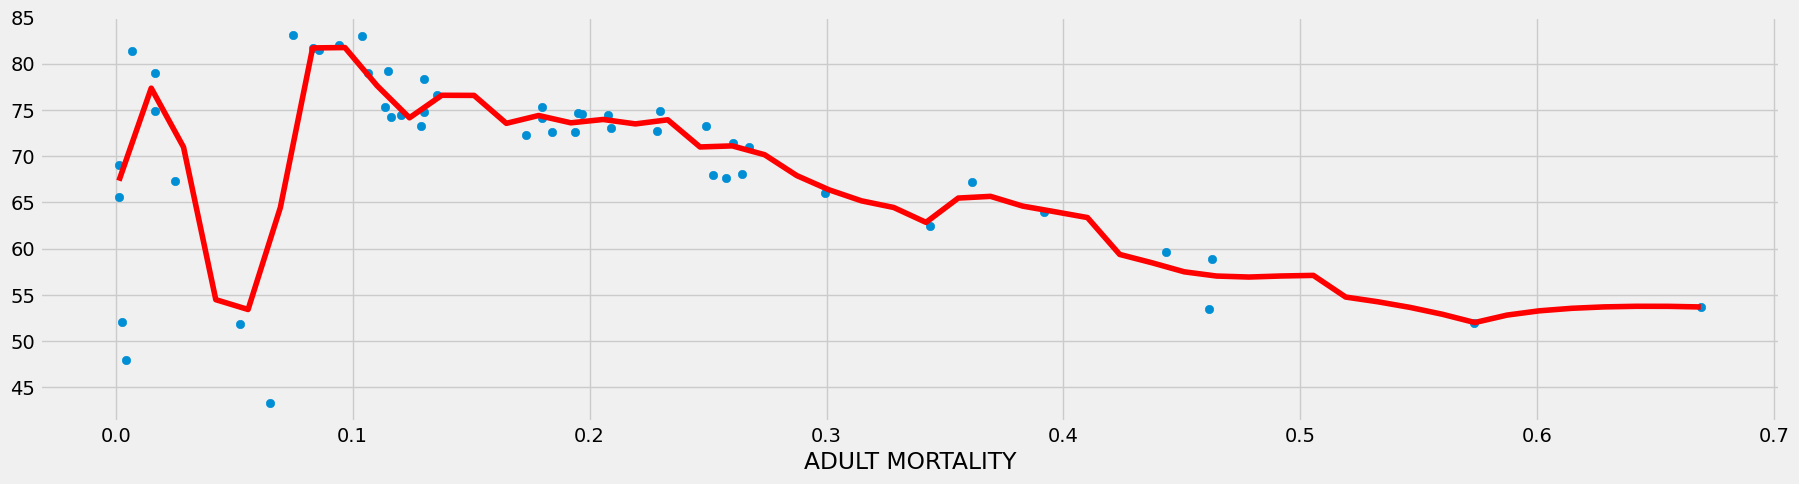

In [77]:
X_b = X_train[['Adult Mortality']].iloc[:50].values
y_b = y_train[:50]

knn_reg = KNeighborsRegressor(n_neighbors =3 , weights = 'distance', p=1)
knn_reg.fit(X_b, y_b)

X_new=np.linspace(X_b.min(), X_b.max(), 50).reshape(50, 1)
y_predict = knn_reg.predict(X_new)

plt.subplots(figsize = (20,5))
plt.plot(X_new, y_predict, c = 'r')
plt.scatter(X_b, y_b)
plt.xlabel('ADULT MORTALITY')

We can see that our chosen KNN Regressor fits this feature well. We can also see that there is one point within the sample which pulls the regressor towards 0.7. If this point were to be removed, we would hace the regressor fitting and ending at the point between 0.5 and 0.6

In [78]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error

## Random Forest Regressor

In [79]:
rf = RandomForestRegressor()

In [80]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Randomized Search
random_search = RandomizedSearchCV(rf, param_dist, cv=5, n_iter=10, random_state=42)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(),
                   param_distributions={'max_depth': [None, 10, 20],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42)

In [81]:
best_rf = random_search.best_estimator_
y_predRF = best_rf.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_predRF))

RMSE: 1.6439443725397973


**Use GridSearch to find the best hyperparameters for Decision Tree Regressor**

In [83]:
#We have considered a few of the hyperparameters here to find which could be the best
dt_param_grid = {'max_depth' : range(1,10),'min_samples_leaf' : range(1,10), 'criterion':['squared_error','absolute_error', 'friedman_mse'], 'splitter': ['best', 'random']}

dtregressor = DecisionTreeRegressor(random_state=0)
dt_best_reg = GridSearchCV(estimator = dtregressor, param_grid = dt_param_grid , return_train_score=True)
dt_best_reg.fit(X_train, y_train)

dt_best_params = dt_best_reg.best_params_
print(dt_best_params)

{'criterion': 'friedman_mse', 'max_depth': 9, 'min_samples_leaf': 6, 'splitter': 'best'}


In [84]:
best_dt_reg = DecisionTreeRegressor(criterion='squared_error', max_depth= 9, min_samples_leaf= 3, splitter= 'best')
best_dt_reg.fit(X_train, y_train)
ydt_predicted = best_dt_reg.predict(X_test)

print('Train score: {:.4f}'.format(best_dt_reg.score(X_train, y_train)))
print('Test score: {:.4f}'.format(best_dt_reg.score(X_test, y_test)))
print('R2_score: {:.4f}'.format(r2_score(y_test,ydt_predicted)))
MSE = np.square(np.subtract(y_test,ydt_predicted)).mean()
print('MSE: {:.4f}'.format(MSE))

Train score: 0.9737
Test score: 0.9291
R2_score: 0.9291
MSE: 6.1408


The chosen paramters for the decision tree has a very good train and test score and also has a relatively low MSE. Decision Trees are prone to overfitting. But as the depth increases, the model will traverse entirely and the train and test scores will obviously get better because the model is now overfit. We need an early stopping condition i.e we need to reduce the depth


## ANALYZING BEST MODEL

In [85]:
print('MSE KNN Regression: {:.4f}'.format(mean_squared_error(y_test,y_predicted)))
print('MSE Linear Regression: {:.4f}'.format(mean_squared_error(y_test,ylinear_predicted)))
print('MSE Random Forrest : {:.4f}'.format(mean_squared_error(y_test,y_predRF)))
print('MSE Gradient Boost Regression: {:.4f}'.format(mean_squared_error(y_test,predictionsGB)))
print('MSE ANN: {:.4f}'.format(mean_squared_error(y_test,y_predann)))
print('MSE Polynomial Regression: {:.4f}'.format(mean_squared_error(y_test,y_pred_poly)))
print('MSE Decision Tree Rgression: {:.4f}'.format(mean_squared_error(y_test,ydt_predicted)))

MSE KNN Regression: 5.1506
MSE Linear Regression: 16.3412
MSE Random Forrest : 2.7026
MSE Gradient Boost Regression: 2.8558
MSE ANN: 6.7457
MSE Polynomial Regression: 7.3003
MSE Decision Tree Rgression: 6.1408


In [86]:
import pandas as pd
from sklearn.metrics import mean_squared_error

# Store model names and their corresponding MSEs
mse_results = {
    
    'Linear Regression': mean_squared_error(y_test, ylinear_predicted),
     
    'Gradient Boosting': mean_squared_error(y_test, predictionsGB),
    'ANN': mean_squared_error(y_test, y_predann),
    'Polynomial Regression': mean_squared_error(y_test, y_pred_poly),
    'Decision Tree': mean_squared_error(y_test, ydt_predicted)
}

# Convert to DataFrame for a clean display
mse_df = pd.DataFrame(list(mse_results.items()), columns=['Model', 'MSE']).sort_values(by='MSE')
print(mse_df)


                   Model        MSE
1      Gradient Boosting   2.855821
4          Decision Tree   6.140830
2                    ANN   6.745659
3  Polynomial Regression   7.300307
0      Linear Regression  16.341212


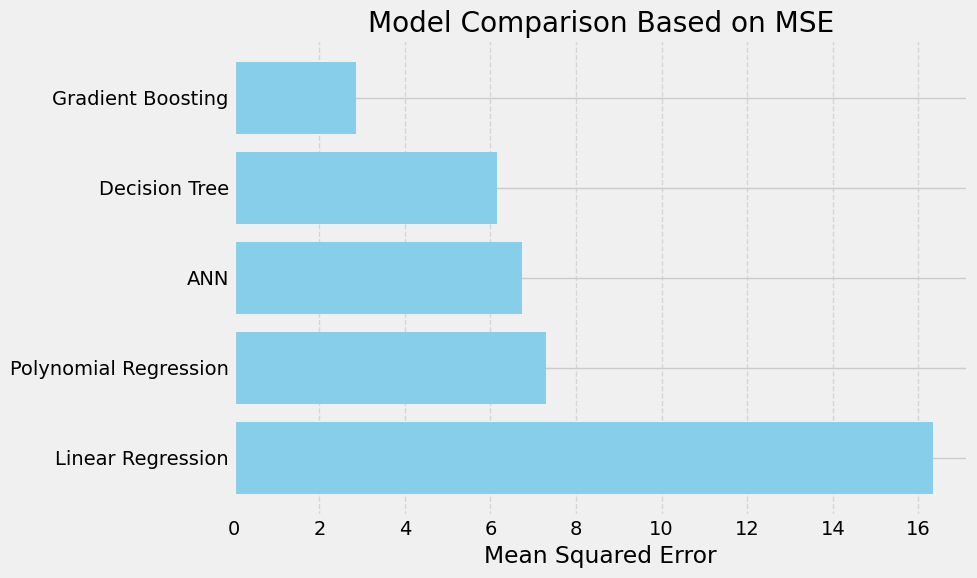

In [87]:
import matplotlib.pyplot as plt

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(mse_df['Model'], mse_df['MSE'], color='skyblue')
plt.xlabel('Mean Squared Error')
plt.title('Model Comparison Based on MSE')
plt.gca().invert_yaxis()  # So the best model (lowest MSE) appears on top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Après avoir entraîné tous les modèles sur le dataset, le Gradient Boosting Regressor s’est révélé le plus performant avec un R² élevé et des erreurs faibles, indiquant une meilleure capacité à prédire l’espérance de vie comparé aux autres modèles tels que la régression linéaire, la régression polynomiale et le réseau de neurone

Le Gradient Boosting Regressor est souvent le meilleur choix pour un dataset comme celui de l’espérance de vie parce que :

    Il gère bien la complexité des données
    

    Il corrige les erreurs successives
    Ce modèle construit plusieurs arbres de décision en série, chacun apprenant à corriger les erreurs du précédent. Cela améliore la précision globale.

    Robuste aux variables bruitées ou peu informatives
    

    Bonne capacité de généralisation
   


Smallest MSE is for KNN, Decision Tree Regression but we know that both these models overfit the data

In [88]:
print('R2 Square score KNN Regression: {:.4f}'.format(r2_score(y_test,y_predicted)))
print('R2 Square score Linear Regression: {:.4f}'.format(r2_score(y_test,ylinear_predicted)))
print('R2 Square score Random forrest : {:.4f}'.format(r2_score(y_test,y_predRF)))
print('R2 Square score Gradient Boost Regression : {:.4f}'.format(r2_score(y_test,predictionsGB)))
print('R2 Square ANN: {:.4f}'.format(r2_score(y_test,y_predann)))
print('R2 Square score Polynomial Regression: {:.4f}'.format(r2_score(y_test,y_pred_poly)))
print('R2 Square score Decision Tree Regression: {:.4f}'.format(r2_score(y_test,ydt_predicted)))

R2 Square score KNN Regression: 0.9405
R2 Square score Linear Regression: 0.8114
R2 Square score Random forrest : 0.9688
R2 Square score Gradient Boost Regression : 0.9670
R2 Square ANN: 0.9221
R2 Square score Polynomial Regression: 0.9157
R2 Square score Decision Tree Regression: 0.9291


In [ ]:
r2_results = {
     
    'Linear Regression': r2_score(y_test, ylinear_predicted),
     
    'Gradient Boosting': r2_score(y_test, predictionsGB),
    'ANN': r2_score(y_test, y_predann),
    'Polynomial Regression': r2_score(y_test, y_pred_poly),
    'Decision Tree': r2_score(y_test, ydt_predicted)
}

# Convert to DataFrame for a clean display
r2_df = pd.DataFrame(list(r2_results.items()), columns=['Model', 'R2 score']).sort_values(by='R2 score')
print(r2_df)

                   Model  R2 score
0      Linear Regression  0.811379
3  Polynomial Regression  0.915735
4          Decision Tree  0.928155
2                    ANN  0.936372
1      Gradient Boosting  0.968340


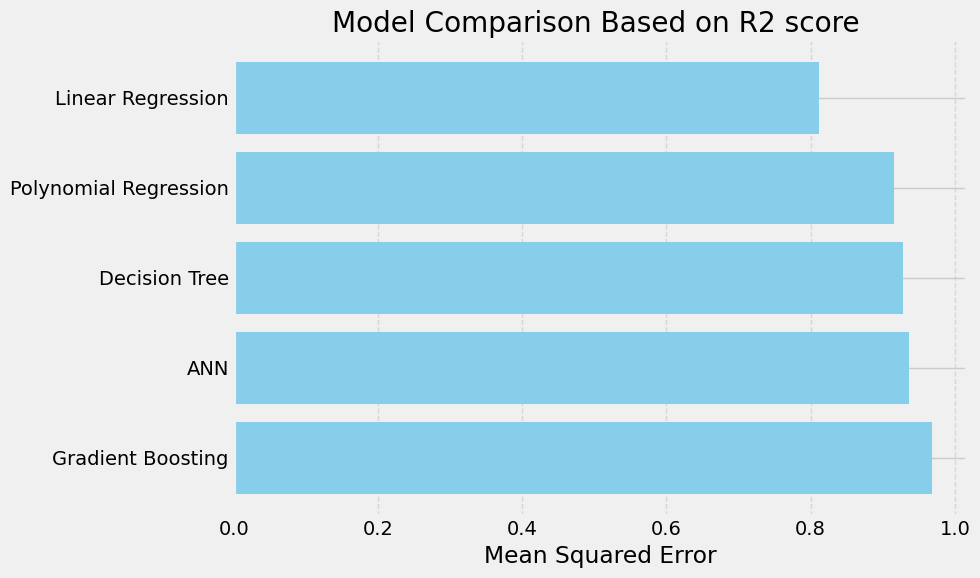

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
plt.barh(r2_df['Model'], r2_df['R2 score'], color='skyblue')
plt.xlabel('Mean Squared Error')
plt.title('Model Comparison Based on R2 score ')
plt.gca().invert_yaxis()  # So the best model (lowest MSE) appears on top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Best R2 score values are for KNN, Polynomial Regression, Decision Tree and Kernel rbf. But we know that KNN and Decision Tree Regression overfit the data

BONUS 
we compared the performance of additional models like svr and lasso regression but we did not work on the modeling 

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
    'SVR (RBF kernel)': SVR(kernel='rbf'),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}


results = []

# Evaluate each model
for name, model in models.items():
    # Use scaled data for models that require it
    if name in ['KNN Regressor', 'SVR (RBF kernel)', 'MLP Regressor']:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        'Model': name,
        'R2 Score': round(r2, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4)
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True))

               Model  R2 Score    RMSE     MAE
0      Random Forest    0.9685  1.6527  1.0712
1      MLP Regressor    0.9207  2.6214  1.8716
2      KNN Regressor    0.9036  2.8899  2.0393
3   SVR (RBF kernel)    0.8425  3.6942  2.5756
4  Linear Regression    0.8114  4.0424  2.9586
5   Ridge Regression    0.8111  4.0453  2.9576
6   Lasso Regression    0.7901  4.2648  3.0567


In [ ]:
# Assuming you've already computed the predictions for each model:
rmse_results = {
    'Linear Regression': mean_squared_error(y_test, ylinear_predicted ),
    'Gradient Boosting': mean_squared_error(y_test, predictionsGB ),
    'ANN': mean_squared_error(y_test, y_predann ),
    'Polynomial Regression': mean_squared_error(y_test, y_pred_poly),
    'Decision Tree': mean_squared_error(y_test, ydt_predicted)
}

# Convert to DataFrame for clean display
rmse_df = pd.DataFrame(list(rmse_results.items()), columns=['Model', 'RMSE']).sort_values(by='RMSE')

print(rmse_df)

                   Model       RMSE
1      Gradient Boosting   2.742861
2                    ANN   5.512408
4          Decision Tree   6.224274
3  Polynomial Regression   7.300307
0      Linear Regression  16.341212


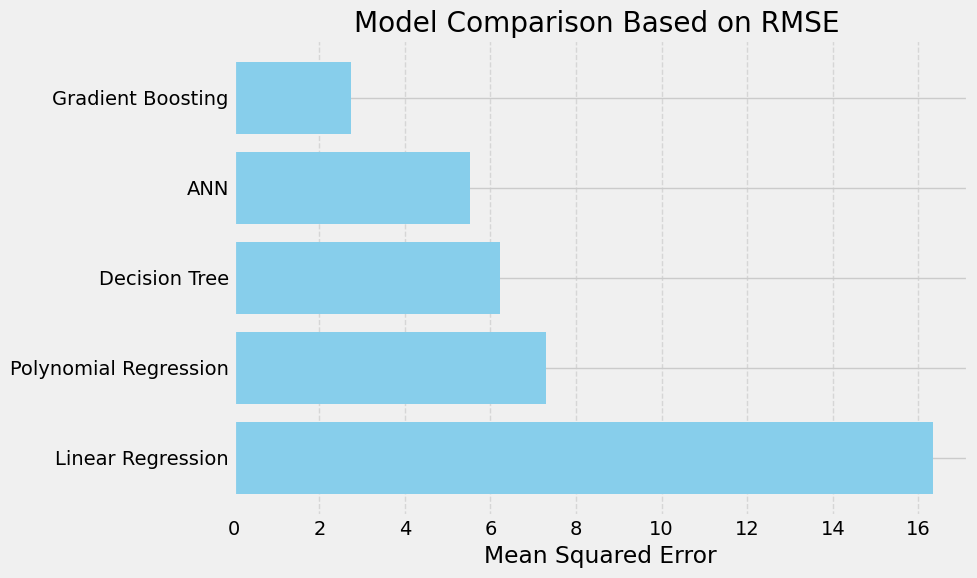

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
plt.barh(rmse_df['Model'], rmse_df['RMSE'], color='skyblue')
plt.xlabel('Mean Squared Error')
plt.title('Model Comparison Based on RMSE ')
plt.gca().invert_yaxis()  # So the best model (lowest MSE) appears on top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()